# 社會網絡分析與地理應用 第四週作業

資訊工程學系 三年級 吳佳泰 S1254059

## Q1. 請針對 networkx 內建的網絡（florentine families graph）回答下列問題：


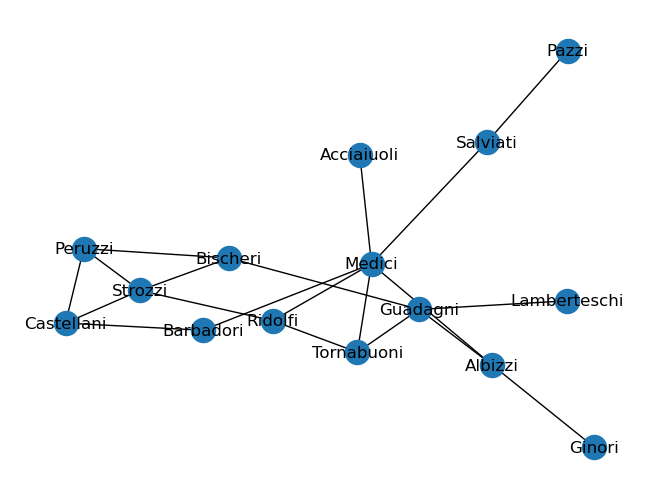

In [2]:
import networkx as nx

g = nx.florentine_families_graph()
nx.draw(g, with_labels=True)

### 1. 最大可以找到多少 level 的 clique？ 並且該 level 的 clique 數量有幾個？

In [3]:
cliques = [x for x in nx.find_cliques(g)]  
max_level = max(len(x) for x in cliques)
counter = 0

for i in cliques:
    if (len(i) == max_level):
        counter += 1

print("(1)Maximum level clique :", max_level)
print("(2)Number of maximum level clique :", counter)

(1)Maximum level clique : 3
(2)Number of maximum level clique : 3


### 2. 哪個節點可能是重要的聯繫者？請以結構洞的觀點回答

* 以 Constraint 的觀點，數值愈大，結構洞數量愈少，因此我們需要找出結構洞數量最多的人(Constraint 最小)，此節點變為最重要的聯繫者

In [4]:
list1 = list(nx.constraint(g).keys())
list2 = list(nx.constraint(g).values())
print("Minimum constraint :" ,list1[list2.index(min(list2))], "； Constraint value :", min(list2))

Minimum constraint : Medici ； Constraint value : 0.2098765432098766


* 以 Effective size 的觀點，數值愈大，結構洞數量愈多，因此我們需要找出結構洞數量最多的人(Effective size最大)，此節點變為最重要的聯繫者

In [5]:
list1 = list(nx.effective_size(g).keys())
list2 = list(nx.effective_size(g).values())
print("Maximum effective size :" , list1[list2.index(max(list2))], "； Effective size value :", max(list2))

Maximum effective size : Medici ； Effective size value : 5.666666666666667


### 3. 此網絡最穩定的核心是多少K-core？

In [6]:
counter = 0

while True:
    core = nx.k_core(g, k = counter)
    counter += 1

    if (not core):
        print("K-core :", counter - 2, "(", nx.k_core(g, k = counter-2), ")")
        print(nx.k_core(g, k = counter-2).nodes)
        break

K-core : 2 ( Graph with 10 nodes and 15 edges )
['Medici', 'Castellani', 'Peruzzi', 'Strozzi', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Bischeri', 'Guadagni']
